# EO-LINCS project: Cube generation for Scientific Case Study (SCS) 3

## Model-Data Fusion for Understanding Carbon State-Flux Relationships Across Space

**Objective**: SCS3 aims to improve the accuracy of ecosystem carbon cycle models by integrating in-situ observation networks with complementary EO products as inputs. The data cubes will be generated in a manner that allows seamless integration within the SINDBAD ecosystem modelling framework.

**Outcomes**: Use a terrestrial carbon model structure that can deliver a process understanding of carbon stateflux relationships across space by leveraging and cross-comparing EO data of biomass and vegetation states 
(fAPAR, LAI, vegetation fraction, etc.) together with ecosystem carbon flux measurements and estimates. 
Additionally, provide open-source novel MDI tools and workflows for community use paving the way for 
adoption by other data-assimilation frameworks.

**Required datasets**:
* [Sentinel-2 L2A from CDSE](https://browser.stac.dataspace.copernicus.eu/?.language=en)
* [ERA-5 land](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview)
* [ESA CCI Biomass](https://climate.esa.int/en/projects/biomass/)

-------------------------------------------------------------

The following notebook shows how the users can load data from various sources defined in `scs3_config.yml` using the `MultiSourceDataStore` tool.

#### **What You Can Do with This Notebook** 
- Generate a configuration file based on fluxtower locations
- Load datasets from various sources as defined in the generated `scs3_config.yml`
- View the progress of each data request to the `MultiSourceDataStore`
- Quickly preview the datasets by plotting them.

#### **Requirements**  
Before you begin, follow these steps:

- Install `xcube-multistore` via conda-forge by running: `conda install --channel conda-forge xcube-multistore`
- To access [EO data via S3 from CDSE](https://documentation.dataspace.copernicus.eu/APIs/S3.html), [generate your S3 credentials](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets) and add them to the `data_stores` section in the `scs3_config.yml` file.  
- To access ERA5-Land data from the Copernicus Climate Data Store, obtain a **CDS Personal Access Token** by creating an account on the [CDS Website](https://cds.climate.copernicus.eu/). After logging in, navigate to your [user page](https://cds.climate.copernicus.eu/profile) to find your Personal Access Token. Add this token to the `data_stores` section in the `scs3_config.yml` file.  


Once you have it installed, you are ready to proceed.

This Multistore mainly works with a file called `scs3_config.yml` which is at the same file level as this notebook.
To understand what goes into the schema, you can read more [here](https://xcube-dev.github.io/xcube-multistore/).

-------------------------------------------------------

Let's import the `MultiSourceDataStore`

In [1]:
import yaml

import pandas as pd
from xcube_multistore import MultiSourceDataStore
from xcube_multistore.utils import get_bbox

You can find out how to fill out the config file by also using this super helpful function `get_config_schema()`. Run it and try expand the fields to learn more about the possible properties that the configuration file accepts along with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).

In [2]:
MultiSourceDataStore.get_config_schema()

This science case requires data from several flux sites. So we define them in a `scs3_sites.csv` file for easier management and access. For the purpose of this example, we will focus on the first 3 sites

In [3]:
sites = pd.read_csv("scs3_sites.csv")
sites = sites.iloc[:3]
sites

,Site ID,latitude,longitude,IGBP
0,AU-Dry,-15.2588,132.3706,SAV
1,AU-How,-12.4943,131.1523,WSA
2,BE-Lon,50.5516,4.7462,CRO


In the following cell, we will create the config object which will then be saved as `scs3_config.yml` for persistance and ready to be read by `MultiSourceDataStore`.

To read more about how this config file is structured, you can find the [Configuration Guide here](https://xcube-dev.github.io/xcube-multistore/config/).

Specifically, we are using the [single dataset object](https://xcube-dev.github.io/xcube-multistore/config/#single-dataset-object) and [data stores](https://xcube-dev.github.io/xcube-multistore/config/#store-object) schemas here.

In [4]:
config = dict(datasets=[])
for index, site in sites.iterrows():
    bbox_final, crs_final = get_bbox(
        site["latitude"], site["longitude"], cube_width=4000, crs_final="utm"
    )

    # append config for Sentinel-2
    config_ds = dict(
        identifier=f"{site['Site ID']}_sen2",
        store="stac-cdse",
        data_id="sentinel-2-l2a",
        open_params=dict(
            time_range=["2019-03-01", "2019-03-15"],
            bbox=bbox_final,
            spatial_res=10,
            crs=f"EPSG:{crs_final.to_epsg()}",
            asset_names=[
                "B01",
                "B02",
                "B03",
                "B04",
                "B05",
                "B06",
                "B07",
                "B08",
                "B8A",
                "B09",
                "B11",
                "B12",
                "SCL",
            ],
        ),
    )
    config["datasets"].append(config_ds)

    # append config for ERA5
    config_ds = dict(
        identifier=f"{site['Site ID']}_era5land",
        store="cds",
        data_id="reanalysis-era5-land",
        open_params=dict(
            variable_names=["2m_temperature", "total_precipitation"],
            time_range=["2019-03-01", "2019-03-15"],
            point=[site["latitude"], site["longitude"]],
            spatial_res=0.1,
        ),
    )
    config["datasets"].append(config_ds)

    # append config for ESA CCI
    config_ds = dict(
        identifier=f"{site['Site ID']}_ccibiomass",
        store="esa_cci",
        grid_mapping=f"{site['Site ID']}_sen2",
        data_id="esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.5-0.100m",
        open_params=dict(
            time_range=["2019-01-01", "2019-12-31"],
        ),
    )
    config["datasets"].append(config_ds)

# define stores
config["data_stores"] = []
# add storage data store
config_store = dict(
    identifier="storage",
    store_id="file",
    store_params=dict(root="data"),
)
config["data_stores"].append(config_store)
# add ESA CCI data store
config_store = dict(
    identifier="esa_cci",
    store_id="cciodp",
)
config["data_stores"].append(config_store)
# add STAC data store
config_store = dict(
    identifier="stac-cdse",
    store_id="stac-cdse-ardc",
    store_params=dict(
        key="<CDSE_S3_key>",
        secret="<CDSE_S3_secret>",
    ),
)
config["data_stores"].append(config_store)
# add CDS data store
config_store = dict(
    identifier="cds",
    store_id="cds",
    store_params=dict(
        endpoint_url="https://cds.climate.copernicus.eu/api",
        cds_api_key="<cds_personal_access_token>",,
        normalize_names=True,
    ),
)
config["data_stores"].append(config_store)

In [5]:
with open("scs3_config.yml", "w") as file:
    yaml.dump(config, file, sort_keys=False)

Now, we can initialize the `MultiSourceDataStore` by passing the path to the scs3_config.yml` which currently is on the same level as this notebook.

By running the cell below, you would start seeing progress tables for each data that you requested in the `scs3_config.yml`.

In [6]:
msds = MultiSourceDataStore("scs3_config.yml")

Dataset identifier,Status,Message,Exception
AU-Dry_sen2,COMPLETED,Dataset 'AU-Dry_sen2' already generated.,-
AU-Dry_era5land,COMPLETED,Dataset 'AU-Dry_era5land' already generated.,-
AU-Dry_ccibiomass,COMPLETED,Dataset 'AU-Dry_ccibiomass' already generated.,-
AU-How_sen2,COMPLETED,Dataset 'AU-How_sen2' already generated.,-
AU-How_era5land,COMPLETED,Dataset 'AU-How_era5land' already generated.,-
AU-How_ccibiomass,COMPLETED,Dataset 'AU-How_ccibiomass' already generated.,-
BE-Lon_sen2,COMPLETED,Dataset 'BE-Lon_sen2' already generated.,-
BE-Lon_era5land,COMPLETED,Dataset 'BE-Lon_era5land' already generated.,-
BE-Lon_ccibiomass,COMPLETED,Dataset 'BE-Lon_ccibiomass' already generated.,-


We can now open the data using the xcube datastore framework API as usual. Note that the multi-source data store requires a data store called `storage`, which is configured in our `config.yml` under the `data_stores` section.

In [7]:
ds = msds.stores.storage.open_data("AU-Dry_sen2.zarr")
ds

<xarray.Dataset> Size: 25MB
Dimensions:      (time: 3, y: 401, x: 401)
Coordinates:
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 24B 2019-03-03T01:27:11.024000 ... 201...
  * x            (x) float64 3kB 2.156e+05 2.156e+05 ... 2.196e+05 2.196e+05
  * y            (y) float64 3kB 8.313e+06 8.313e+06 ... 8.309e+06 8.309e+06
Data variables: (12/13)
    B01          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B02          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B03          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B04          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B05          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B06          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    ...           ...
    B08          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B09          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B11          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B12          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    B8A          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    SCL          (time, y, x) float32 2MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://stac.dataspace.copernicus.eu/v1
    stac_item_ids:       {'2019-03-03T01:27:11.024000': ['S2A_MSIL2A_20190303...
    xcube_stac_version:  1.1.0

We can now select a variable for one timestep and plot it for a quick preview of the data

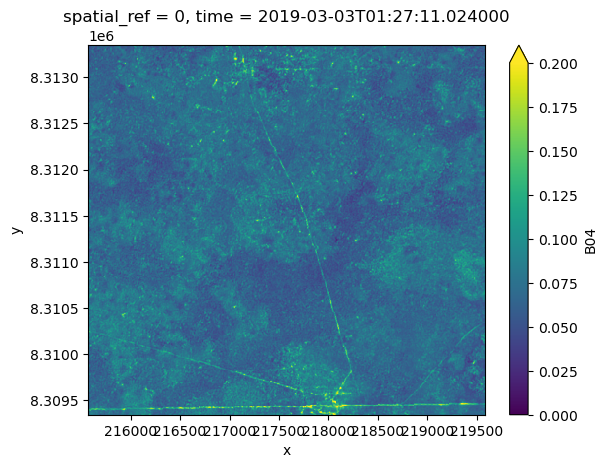

In [8]:
ds.B04.isel(time=0).plot(vmin=0., vmax=0.2)

In [9]:
ds = msds.stores.storage.open_data("AU-Dry_era5land.zarr")
ds

<xarray.Dataset> Size: 12kB
Dimensions:  (time: 360)
Coordinates:
    expver   (time) <U4 6kB dask.array<chunksize=(360,), meta=np.ndarray>
    lat      float64 8B ...
    lon      float64 8B ...
    number   int64 8B ...
  * time     (time) datetime64[ns] 3kB 2019-03-01 ... 2019-03-15T23:00:00
Data variables:
    t2m      (time) float32 1kB dask.array<chunksize=(360,), meta=np.ndarray>
    tp       (time) float32 1kB dask.array<chunksize=(360,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-09-11T11:57 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

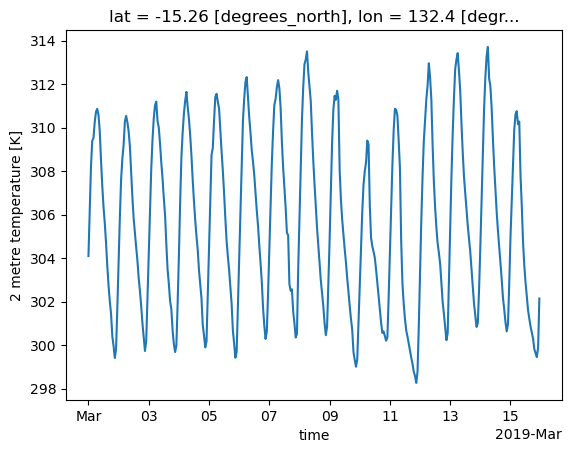

In [10]:
ds.t2m.plot()

In [11]:
ds = msds.stores.storage.open_data("AU-Dry_ccibiomass.zarr")
ds

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 1, y: 401, x: 401)
Coordinates:
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 8B 2019-07-02T11:59:59
  * x            (x) float64 3kB 2.156e+05 2.156e+05 ... 2.196e+05 2.196e+05
  * y            (y) float64 3kB 8.313e+06 8.313e+06 ... 8.309e+06 8.309e+06
Data variables:
    agb          (time, y, x) float64 1MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
    agb_sd       (time, y, x) float64 1MB dask.array<chunksize=(1, 401, 401), meta=np.ndarray>
Attributes: (12/19)
    Conventions:                CF-1.7
    date_created:               2025-09-11T14:05:16.016542
    date_modified:              2025-09-11T14:05:22.454435
    geospatial_bounds:          POLYGON((132.34933332965429 -15.2782222218250...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         -15.237333331825397
    ...                         ...
    history:                    [{'cube_params': {'time_range': ['2019-01-01T...
    processing_level:           L4
    time_coverage_duration:     P364DT23H59M59S
    time_coverage_end:          2019-12-31T23:59:59
    time_coverage_start:        2019-01-01T00:00:00
    title:                      esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-p...

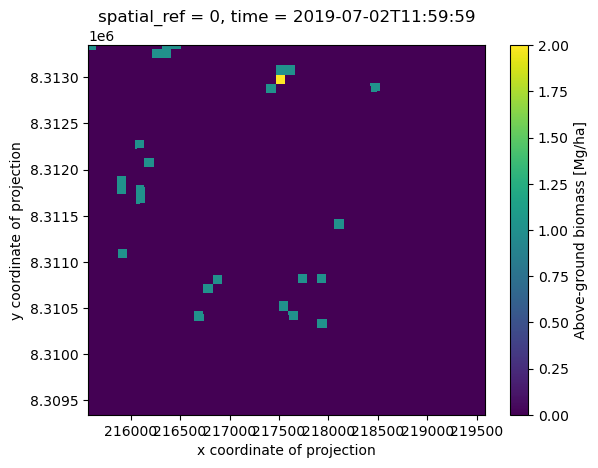

In [12]:
ds["agb"].plot()